In [1]:
import awkward as ak
from coffea import nanoevents 

In [2]:
file_path = "root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-80p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-80p0_v3_part-0.root"
events = nanoevents.NanoEventsFactory.from_root(
    {file_path: "Events"},
    schemaclass=nanoevents.NanoAODSchema,
).events()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


In [3]:
import awkward as ak
import numpy as np
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

def is_rootcompat(a):
    """
    We use this helper to determine if an array is 'simple' enough to be saved.
    Our goal is to filter out complex 3D objects (like .children) that cause 
    'NotImplementedError' in Parquet, while ensuring we keep masked arrays 
    (OptionTypes) which are essential for indices like genPartIdxMother.
    """
    t = ak.type(a)
    
    # Unwrap the type layers to find the core primitive
    if isinstance(t, ak.types.ArrayType): 
        t = t.content
    if isinstance(t, ak.types.ListType): 
        t = t.content
    if isinstance(t, ak.types.OptionType): 
        t = t.content

    # Return True only if the core is a NumpyType (number/bool)
    return isinstance(t, ak.types.NumpyType)

def to_flat_parquet(events, filename):
    """
    We implemented this custom saver to write NanoAOD-style events to Parquet.
    Standard ak.to_parquet saves nested records, but NanoAODSchema requires 
    a 'flat' structure (e.g., Muon_pt, nMuon) to automatically rebuild 
    objects and cross-references upon reloading.
    """
    flat_arrays = {}
    
    print(f"Scanning {len(events.fields)} branches...")
    for bname in events.fields:
        branch = events[bname]
        
        # Identify collections by checking if they have fields and are jagged (ndim > 1).
        # This distinguishes them from simple global variables like 'run' or 'event'.
        if branch.fields and branch.ndim > 1:
            
            # Explicitly save the counts array (e.g., nGenPart) using the 'n' prefix.
            # NanoAODSchema looks for this specific pattern to register the branch 
            # as a proper Collection, enabling methods like _apply_global_index.
            flat_arrays[f"n{bname}"] = ak.num(branch)
            
            for sub in branch.fields:
                sub_array = branch[sub]
                
                # Sanitize OptionType arrays (masked values) by filling None with -1.
                # This is critical for indices (like genPartIdxMother). In ROOT, these are
                # integers where -1 means 'no parent'. Parquet treats them as Nulls.
                # Revert to -1 to match what NanoAODSchema expects for index math.
                if "OptionType" in str(ak.type(sub_array.layout)):
                    sub_array = ak.fill_none(sub_array, -1)
                
                # Strip parameters to avoid carrying over broken factory references 
                # from the previous file, ensuring a clean slate for the new schema.
                clean_array = ak.without_parameters(sub_array)
                
                # Filter out derived fields (like .children or .mass) using the helper.
                # Only save the raw ingredients (pt, eta, phi, indices) 
                # and let the Schema re-derive the complex logic when we load it back.
                if is_rootcompat(clean_array):
                    flat_arrays[f"{bname}_{sub}"] = ak.to_packed(clean_array)
                    
        # If it's not a collection, treat it as a simple column (e.g., MET, run).
        else:
            clean_array = ak.without_parameters(branch)
            if is_rootcompat(clean_array):
                flat_arrays[bname] = ak.to_packed(clean_array)

    # Zip the flat arrays into a single table with depth_limit=1.
    # This creates the Event-level grouping that allows us to save everything 
    # to a single Parquet file while keeping the structure compatible with uproot.
    print(f"Saving compatible columns to {filename}...")
    flat_table = ak.zip(flat_arrays, depth_limit=1)
    ak.to_parquet(flat_table, filename)
    print("Success!")

In [4]:
to_flat_parquet(events, "skim_test_final.parquet")
print("\nReloading from Parquet...")
restored_events = NanoEventsFactory.from_parquet(
    "skim_test_final.parquet", 
    schemaclass=NanoAODSchema
).events()

print("\n--- Verification ---")
print("Flags:", restored_events.GenPart.hasFlags("isPrompt"))
print("Children:", restored_events.GenPart.children)

Scanning 79 branches...
Saving compatible columns to skim_test_final.parquet...
Success!

Reloading from Parquet...

--- Verification ---
Flags: [[True, True, True, True, True, ..., True, False, False, False, False], ...]
Children: [[[{eta: ??, mass: ??, phi: ??, pt: ??, genPartIdxMother: ??, ...}], ...], ...]


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


In [5]:
import awkward as ak
import numpy as np

def get_primitive_type(array):
    """
    We use this helper to inspect the deepest layer of an Awkward array.
    This allows us to correctly handle jagged arrays (ListType) when 
    determining if we should perform floating-point comparisons.
    """
    t = ak.type(array)
    if isinstance(t, ak.types.ArrayType): 
        t = t.content
    while isinstance(t, ak.types.ListType):
        t = t.content
    if isinstance(t, ak.types.OptionType):
        t = t.content
    if isinstance(t, ak.types.NumpyType):
        return t.primitive
    return None

def validate_roundtrip(original, reloaded, float_tolerance=1e-5):
    """
    We perform a rigorous, field-by-field comparison between the original 
    in-memory events and the events reloaded from our Parquet skim.
    """
    print(f"--- STARTING VALIDATION ---")
    
    # Check the simplest metric: do we have the same number of events?
    # A mismatch here would indicate a catastrophic failure in saving.
    if len(original) != len(reloaded):
        print(f"❌ FATAL: Event count mismatch! {len(original)} vs {len(reloaded)}")
        return
    print("✓ Event counts match")

    failures = []
    
    # Define a subset of critical collections to check to keep the output readable,
    # but this list covers the main physics objects we care about.
    collections_to_check = [f for f in original.fields if f in ["GenPart", "Muon", "Electron", "Jet", "Photon"]]
    
    for col in collections_to_check:
        print(f"\nChecking Collection: {col}...")
        
        if col not in reloaded.fields:
            print(f"  ❌ Missing in reloaded!")
            failures.append(f"{col} missing")
            continue

        o_col = original[col]
        r_col = reloaded[col]

        # Check that every event has the exact same number of objects (e.g. muons).
        # This ensures we didn't lose any particles during the flatten/unflatten process.
        o_counts = ak.num(o_col)
        r_counts = ak.num(r_col)
        
        if not ak.all(o_counts == r_counts):
            print(f"  ❌ Counts mismatch in {col}!")
            failures.append(f"{col} counts")
            continue
        print(f"  ✓ Counts match per event")
        
        # Iterate over the properties present in the RELOADED data.
        for prop in r_col.fields:
            # Skip checking fields that were in the original but not saved (like .children),
            # as we intentionally dropped those to avoid errors.
            # if prop in ["children", "distinctChildren", "matched_gen", "matched_jet", "mass"]:
            #     continue
            if prop not in o_col.fields:
                continue

            o_val = o_col[prop]
            r_val = r_col[prop]
            
            # Sanitize masked values (None) by converting them to -999.
            # This allows us to use numpy comparison functions which cannot handle None.
            if "OptionType" in str(ak.type(o_val.layout)) or "OptionType" in str(ak.type(r_val.layout)):
                o_val = ak.fill_none(o_val, -999)
                r_val = ak.fill_none(r_val, -999)
            
            try:
                prim = get_primitive_type(r_val)
                
                # Use a tolerance check for floats to account for potential precision 
                # differences during serialization, though usually Parquet is exact.
                # We explicitly handle NaNs to avoid false mismatches.
                if prim and 'float' in prim:
                    o_val = ak.nan_to_num(o_val, nan=-999)
                    r_val = ak.nan_to_num(r_val, nan=-999)
                    diff = np.abs(o_val - r_val)
                    match = ak.all(diff < float_tolerance)
                
                # For integers and booleans, demand an exact match.
                else:
                    match = ak.all(o_val == r_val)
                
                if match:
                    print(f"    ✓ {prop} matches")
                else:
                    print(f"    ❌ {prop} MISMATCH")
                    failures.append(f"{col}.{prop}")
            except Exception as e:
                print(f"    ⚠️ Error checking {prop}: {e}")

    # Perform a special check on 'children'.
    # This is the ultimate test of the Schema. If the children structure
    # matches, it proves that the Schema successfully used the indices saved 
    # to reconstruct the entire parent-child graph.
    print(f"\nChecking Cross-References:")
    if "GenPart" in reloaded.fields:
        try:
            o_child = ak.num(original.GenPart.children, axis=2)
            r_child = ak.num(reloaded.GenPart.children, axis=2)
            if ak.all(o_child == r_child):
                 print("  ✓ GenPart.children structure matches!")
            else:
                 print("  ❌ GenPart.children structure mismatch.")
                 failures.append("GenPart.children")
        except Exception as e:
            print(f"  ❌ GenPart.children failed: {e}")

    print("\n--- VALIDATION SUMMARY ---")
    if not failures:
        print("✅ SUCCESS: All fields match!")
    else:
        print(f"❌ FAILED: {len(failures)} mismatches found.")
        print(failures)

In [6]:
validate_roundtrip(events, restored_events)

--- STARTING VALIDATION ---
✓ Event counts match

Checking Collection: GenPart...
  ✓ Counts match per event
    ✓ eta matches
    ✓ mass matches
    ✓ phi matches
    ✓ pt matches
    ✓ genPartIdxMother matches
    ✓ pdgId matches
    ✓ status matches
    ✓ statusFlags matches
    ✓ vx matches
    ✓ vy matches
    ✓ vz matches
    ✓ px matches
    ✓ py matches
    ✓ pz matches
    ✓ genPartIdxMotherG matches
    ✓ distinctParentIdxG matches
    ✓ childrenIdxG matches
    ✓ distinctChildrenIdxG matches
    ✓ distinctChildrenDeepIdxG matches

Checking Collection: Muon...
  ✓ Counts match per event
    ✓ dxy matches
    ✓ dxyErr matches
    ✓ dxybs matches
    ✓ dz matches
    ✓ dzErr matches
    ✓ eta matches
    ✓ ip3d matches
    ✓ jetPtRelv2 matches
    ✓ jetRelIso matches
    ✓ mass matches
    ✓ miniPFRelIso_all matches
    ✓ miniPFRelIso_chg matches
    ✓ pfRelIso03_all matches
    ✓ pfRelIso03_chg matches
    ✓ pfRelIso04_all matches
    ✓ phi matches
    ✓ pt matches
    ✓ ptErr

Plotting GenPart.pt...


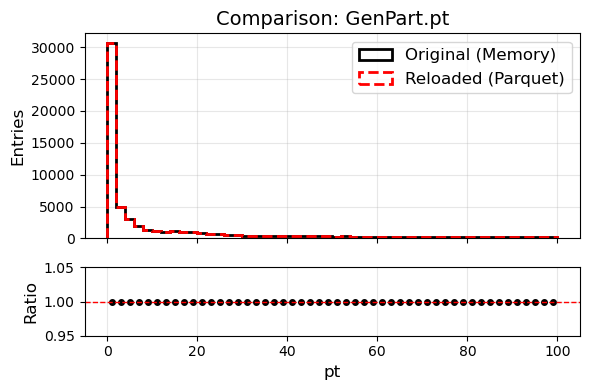

  Stats for GenPart.pt:
    Original: N=74124, Mean=46.3150, Std=74.3366
    Reloaded: N=74124, Mean=46.3150, Std=74.3366
--------------------------------------------------
Plotting GenPart.eta...


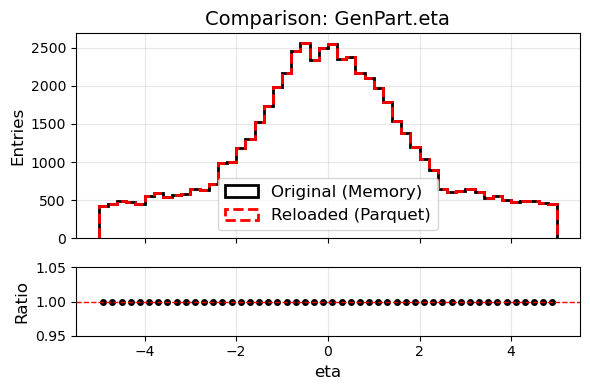

  Stats for GenPart.eta:
    Original: N=74124, Mean=4.2072, Std=6903.5377
    Reloaded: N=74124, Mean=4.2072, Std=6903.5377
--------------------------------------------------
Plotting GenPart.phi...


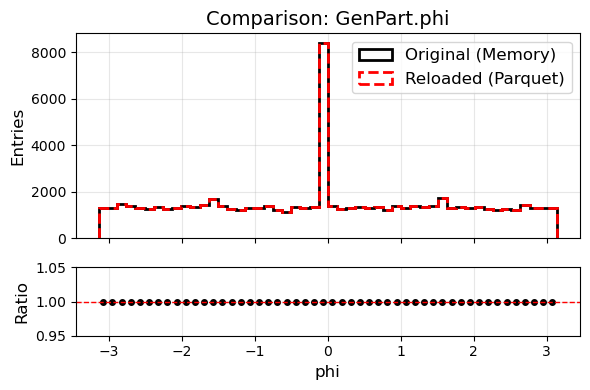

  Stats for GenPart.phi:
    Original: N=74124, Mean=0.0080, Std=1.7348
    Reloaded: N=74124, Mean=0.0080, Std=1.7348
--------------------------------------------------
Plotting GenPart.pdgId...


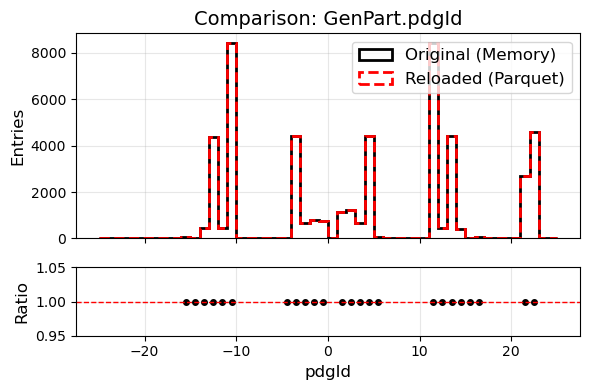

  Stats for GenPart.pdgId:
    Original: N=74124, Mean=23.2530, Std=457.8507
    Reloaded: N=74124, Mean=23.2530, Std=457.8507
--------------------------------------------------


In [7]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

def plot_comparison(original, reloaded, collection, variable, bins=50, range=None):
    """
    Plots overlapping histograms and a ratio plot for a specific variable.
    Explicitly DROPS None values to ensure we are comparing real physics data, 
    not dummy fillers.
    """
    print(f"Plotting {collection}.{variable}...")
    
    # Access Data safely
    try:
        arr_orig = original[collection][variable]
        arr_reload = reloaded[collection][variable]
    except KeyError:
        print(f"Skipping {collection}.{variable} - field not found.")
        return

    # Flatten and Clean
    # CRITICAL: We use ak.drop_none() to remove missing values.
    # This ensures we are plotting REAL data, not the -999 dummies from the validation script.
    flat_orig = ak.drop_none(ak.flatten(arr_orig, axis=None))
    flat_reload = ak.drop_none(ak.flatten(arr_reload, axis=None))

    # Setup Canvas
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(6, 4), 
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )
    
    # Main Plot (Overlapping Histograms)
    # We use 'step' style to clearly see the lines overlap
    counts_orig, edges, _ = ax1.hist(
        flat_orig, bins=bins, range=range, 
        label='Original (Memory)', histtype='step', 
        linewidth=2, color='black', density=False
    )
    counts_reload, _, _ = ax1.hist(
        flat_reload, bins=bins, range=range, 
        label='Reloaded (Parquet)', histtype='step', 
        linewidth=2, color='red', linestyle='--', density=False
    )
    
    ax1.set_title(f"Comparison: {collection}.{variable}", fontsize=14)
    ax1.set_ylabel("Entries", fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(alpha=0.3)

    # Ratio Plot (The Truth Test)
    # Calculate ratio, handling division by zero safely
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = counts_reload / counts_orig
    
    # Center points for ratio plot
    centers = 0.5 * (edges[1:] + edges[:-1])
    
    ax2.plot(centers, ratio, 'ko', markersize=4)
    ax2.axhline(1.0, color='red', linestyle='--', linewidth=1)
    ax2.set_ylim(0.95, 1.05) # Tight zoom to prove exactness
    ax2.set_ylabel("Ratio", fontsize=12)
    ax2.set_xlabel(f"{variable}", fontsize=12)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Numerical Stats (Backup Check)
    print(f"  Stats for {collection}.{variable}:")
    print(f"    Original: N={len(flat_orig)}, Mean={ak.mean(flat_orig):.4f}, Std={ak.std(flat_orig):.4f}")
    print(f"    Reloaded: N={len(flat_reload)}, Mean={ak.mean(flat_reload):.4f}, Std={ak.std(flat_reload):.4f}")
    print("-" * 50)

# --- RUN THE TESTS ---
# Pick variables with different shapes and physics meanings to be thorough
plot_comparison(events, restored_events, "GenPart", "pt", bins=50, range=(0, 100))
plot_comparison(events, restored_events, "GenPart", "eta", bins=50, range=(-5, 5))
plot_comparison(events, restored_events, "GenPart", "phi", bins=50, range=(-3.14, 3.14))
# Also check integer counts to be sure structure is preserved
plot_comparison(events, restored_events, "GenPart", "pdgId", bins=50, range=(-25, 25))